# 9. Autoencoders 🔄

En este notebook aprenderás los fundamentos de los autoencoders, incluyendo autoencoders simples, denoising y variacionales (VAE), con ejemplos prácticos en TensorFlow/Keras.

✨ **Highlights:**
- Autoencoder simple con visualización de reconstrucciones
- Denoising autoencoder: limpiar imágenes con ruido
- VAE: espacio latente continuo y generación de nuevos dígitos
- Comparación de error de reconstrucción entre los tres tipos

## Objetivo
- Comprender la teoría y arquitectura de los autoencoders.
- Implementar un autoencoder simple, un denoising autoencoder y un VAE.
- Visualizar reconstrucciones y el espacio latente.
- Aplicar buenas prácticas para entrenamiento eficiente.

## Prerequisitos

> 📌 **Prerequisitos:** Haber completado los notebooks [04 (MLP)](./04_redes_neuronales_capa_densa.ipynb) y [08 (GANs)](./08_gans.ipynb).

- Conceptos de redes neuronales y modelos generativos.

## 1. Introducción teórica

Un autoencoder comprime datos en una representación de menor dimensión y luego los reconstruye.

| Tipo | Uso principal | Característica |
|------|---------------|----------------|
| **Simple** | Reducción de dimensionalidad | Comprime y reconstruye |
| **Denoising** | Eliminación de ruido | Entrena con datos ruidosos |
| **Variacional (VAE)** | Generación de datos | Espacio latente continuo y muestreable |

## 2. Importación de librerías

In [1]:
import random
import numpy as np
import os
import logging
import time

# === Reproducibilidad ===
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Suprimir logs de XLA/oneDNN antes de importar TF
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(SEED)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# === Información del dispositivo ===
print(f'TensorFlow: {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs disponibles: {len(gpus)}')
if gpus:
    for gpu in gpus:
        print(f'  ✅ {gpu.name}')
else:
    print('  ⚠️  Sin GPU — se usará CPU')
print('─' * 50)

TensorFlow: 2.20.0
GPUs disponibles: 1
  ✅ /physical_device:GPU:0
──────────────────────────────────────────────────


## 3. Autoencoder simple

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0570 - val_loss: 0.0310
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0248 - val_loss: 0.0200
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0186 - val_loss: 0.0166
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0160 - val_loss: 0.0147
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0145 - val_loss: 0.0135
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0134 - val_loss: 0.0125
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0126 - val_loss: 0.0119
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0120 - val_loss: 0.0115
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0116 - val_loss: 0.0111
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0113 - val_loss: 0.0108
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0111 - val_loss: 0.0106
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

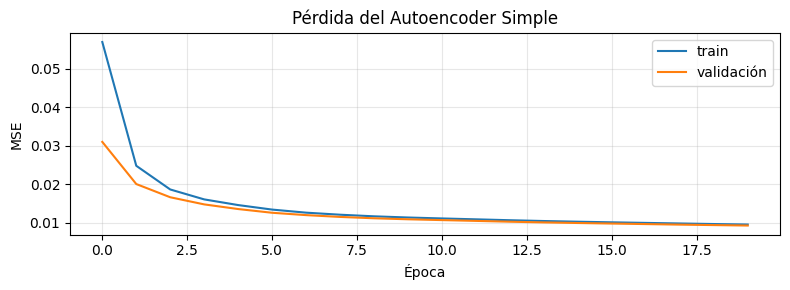

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_train_flat = X_train.reshape(-1, 28*28)
X_test_flat = X_test.reshape(-1, 28*28)

encoding_dim = 32
input_img = keras.Input(shape=(784,))
encoded = keras.layers.Dense(128, activation='relu')(input_img)
encoded = keras.layers.Dense(encoding_dim, activation='relu')(encoded)
decoded = keras.layers.Dense(128, activation='relu')(encoded)
decoded = keras.layers.Dense(784, activation='sigmoid')(decoded)

autoencoder = keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True)

start = time.time()
hist_ae = autoencoder.fit(
    X_train_flat, X_train_flat,
    epochs=20, batch_size=256, shuffle=True,
    validation_data=(X_test_flat, X_test_flat),
    callbacks=[early_stop], verbose=1)
t_ae = time.time() - start

mse_ae = autoencoder.evaluate(X_test_flat, X_test_flat, verbose=0)
print(f'\n✅ Autoencoder simple | MSE test: {mse_ae:.6f} | Tiempo: {t_ae:.1f}s')

# Curva de entrenamiento
plt.figure(figsize=(8, 3))
plt.plot(hist_ae.history['loss'], label='train')
plt.plot(hist_ae.history['val_loss'], label='validación')
plt.title('Pérdida del Autoencoder Simple')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visualización de reconstrucciones

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


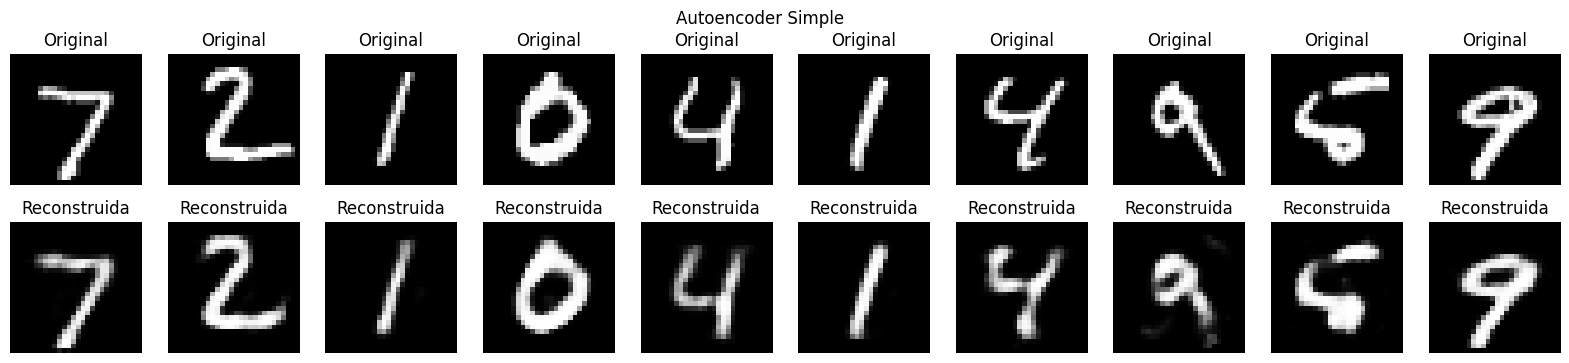

In [3]:
decoded_imgs = autoencoder.predict(X_test_flat)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title('Original')
    plt.axis('off')
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title('Reconstruida')
    plt.axis('off')
plt.suptitle('Autoencoder Simple')
plt.show()

## 4. Denoising Autoencoder

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0649 - val_loss: 0.0410
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0367 - val_loss: 0.0328
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0312 - val_loss: 0.0292
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0284 - val_loss: 0.0271
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0266 - val_loss: 0.0255
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0252 - val_loss: 0.0243
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0241 - val_loss: 0.0233
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0232 - val_loss: 0.0226
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0226 - val_loss: 0.0222
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0221 - val_loss: 0.0218

✅ Denoising AE | MSE test: 0.021805 | Tiempo: 12.6s
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


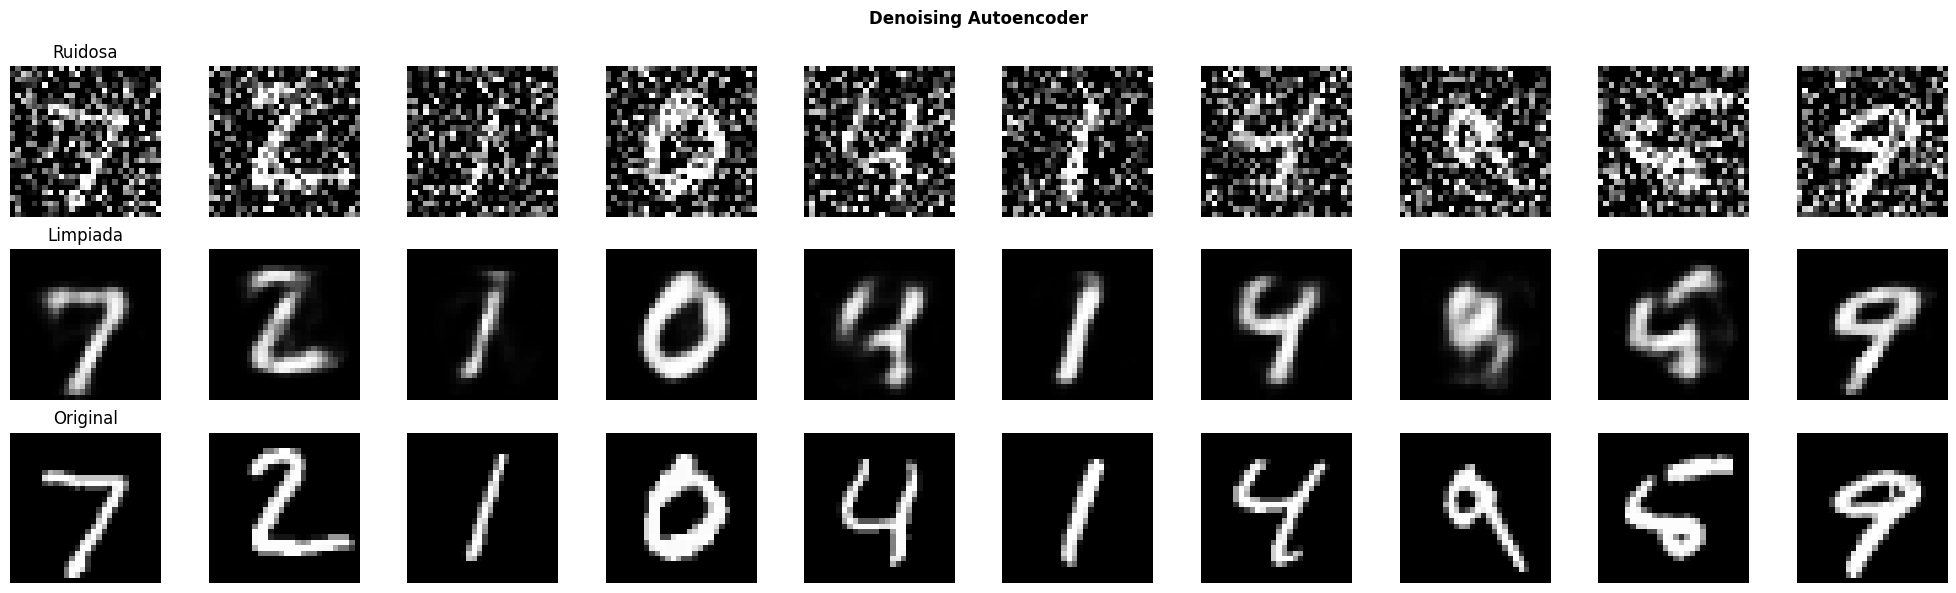

In [4]:
noise_factor = 0.5
X_train_noisy = np.clip(X_train_flat + noise_factor * np.random.normal(0, 1, X_train_flat.shape), 0., 1.)
X_test_noisy = np.clip(X_test_flat + noise_factor * np.random.normal(0, 1, X_test_flat.shape), 0., 1.)

denoising_ae = keras.models.clone_model(autoencoder)
denoising_ae.compile(optimizer='adam', loss='mse')

early_stop_dn = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True)

start = time.time()
hist_dn = denoising_ae.fit(
    X_train_noisy, X_train_flat,
    epochs=10, batch_size=256, shuffle=True,
    validation_data=(X_test_noisy, X_test_flat),
    callbacks=[early_stop_dn], verbose=1)
t_dn = time.time() - start

mse_dn = denoising_ae.evaluate(X_test_noisy, X_test_flat, verbose=0)
print(f'\n✅ Denoising AE | MSE test: {mse_dn:.6f} | Tiempo: {t_dn:.1f}s')

n = 10
decoded_noisy = denoising_ae.predict(X_test_noisy)

plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(X_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title('Ruidosa') if i == 0 else None
    plt.axis('off')
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_noisy[i].reshape(28, 28), cmap='gray')
    plt.title('Limpiada') if i == 0 else None
    plt.axis('off')
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(X_test[i], cmap='gray')
    plt.title('Original') if i == 0 else None
    plt.axis('off')
plt.suptitle('Denoising Autoencoder', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Variational Autoencoder (VAE)

El VAE aprende un espacio latente **continuo y muestreable**, permitiendo generar nuevos datos interpolando en el espacio latente.

In [5]:
latent_dim = 2

class Sampling(keras.layers.Layer):
    """Muestreo reparametrizado: z = mu + sigma * epsilon."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = keras.random.normal(shape=keras.ops.shape(z_mean))
        return z_mean + keras.ops.exp(0.5 * z_log_var) * epsilon

class VAE(keras.Model):
    def __init__(self, latent_dim):
        super().__init__()
        self.enc1          = keras.layers.Dense(256, activation='relu')
        self.z_mean_layer  = keras.layers.Dense(latent_dim, name='z_mean')
        self.z_log_var_layer = keras.layers.Dense(latent_dim, name='z_log_var')
        self.sampling      = Sampling()
        self.dec1          = keras.layers.Dense(256, activation='relu')
        self.dec_out       = keras.layers.Dense(784, activation='sigmoid')

    def encode(self, x):
        h = self.enc1(x)
        return self.z_mean_layer(h), self.z_log_var_layer(h)

    def decode(self, z):
        return self.dec_out(self.dec1(z))

    def call(self, x, training=False):
        z_mean, z_log_var = self.encode(x)
        z = self.sampling([z_mean, z_log_var])
        x_decoded = self.decode(z)
        # KL divergence añadida como pérdida auxiliar (add_loss sólo funciona en subclassed models)
        kl_loss = -0.5 * keras.ops.mean(
            keras.ops.sum(
                1 + z_log_var - keras.ops.square(z_mean) - keras.ops.exp(z_log_var),
                axis=-1
            )
        )
        self.add_loss(kl_loss)
        return x_decoded

vae = VAE(latent_dim)
vae.compile(optimizer='adam', loss='binary_crossentropy')

early_stop_vae = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True)

start = time.time()
hist_vae = vae.fit(
    X_train_flat, X_train_flat,
    epochs=15, batch_size=256,
    validation_data=(X_test_flat, X_test_flat),
    callbacks=[early_stop_vae], verbose=1)
t_vae = time.time() - start
print(f'\n✅ VAE | Tiempo: {t_vae:.1f}s')

Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.3581 - val_loss: 0.2702
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2674 - val_loss: 0.2652
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2646 - val_loss: 0.2636
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2637 - val_loss: 0.2632
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2633 - val_loss: 0.2629
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2632 - val_loss: 0.2629
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2631 - val_loss: 0.2628
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2631 - val_loss: 0.2628
Epoch 9/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2631 - val_loss: 0.2628
Epoch 10/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2630 - val_loss: 0.2628
Epoch 11/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2630 - val_loss: 0.2627
Epoch 12/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

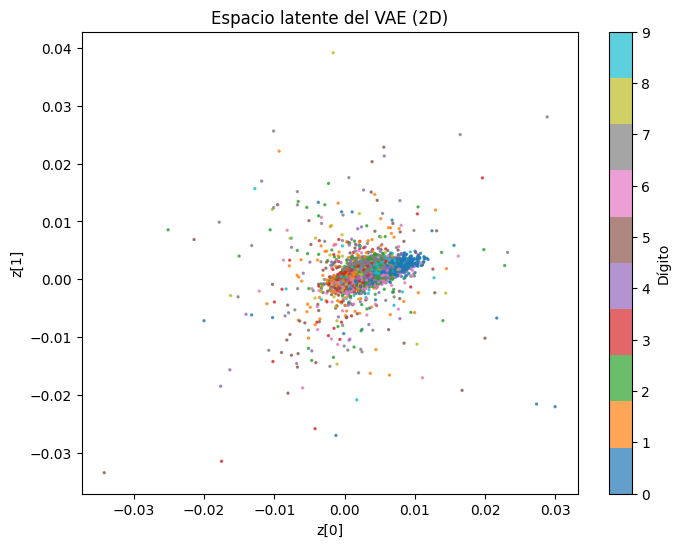

In [6]:
# Visualizar espacio latente
z_test_mean, _ = vae.encode(X_test_flat)
z_test = z_test_mean.numpy()

plt.figure(figsize=(8, 6))
plt.scatter(z_test[:, 0], z_test[:, 1], c=y_test, cmap='tab10', s=2, alpha=0.7)
plt.colorbar(label='Dígito')
plt.title('Espacio latente del VAE (2D)')
plt.xlabel('z[0]')
plt.ylabel('z[1]')
plt.show()

## 5b. Comparación de los tres autoencoders

            Modelo  MSE test (reconstrucción)  Tiempo entrenamiento (s)  Espacio latente (dims) Genera nuevos datos
Autoencoder simple                   0.009210                      24.1                      32                  No
      Denoising AE                   0.021805                      12.6                      32                  No
               VAE                   0.067535                      24.1                       2                  Sí


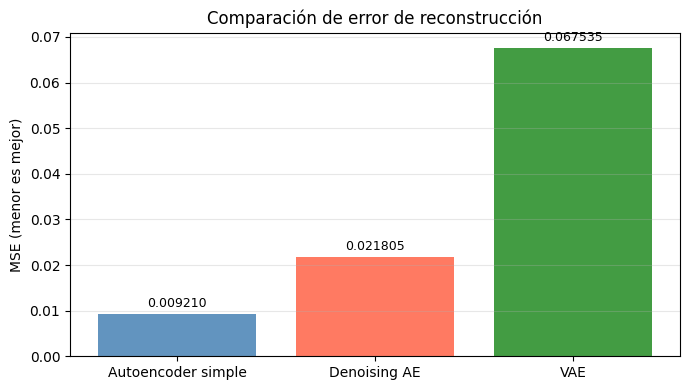


💡 El VAE tiene MSE mayor porque optimiza también la regularización KL — 
   el espacio latente más estructurado compensa el ligero aumento en reconstrucción.


In [7]:
import pandas as pd

# Reconstrucción VAE en datos limpios
mse_vae_test = np.mean((vae.predict(X_test_flat, verbose=0) - X_test_flat) ** 2)

comparison = pd.DataFrame({
    'Modelo': ['Autoencoder simple', 'Denoising AE', 'VAE'],
    'MSE test (reconstrucción)': [mse_ae, mse_dn, mse_vae_test],
    'Tiempo entrenamiento (s)': [round(t_ae, 1), round(t_dn, 1), round(t_vae, 1)],
    'Espacio latente (dims)': [encoding_dim, encoding_dim, latent_dim],
    'Genera nuevos datos': ['No', 'No', 'Sí'],
})
print(comparison.to_string(index=False))

# Gráfico comparativo de MSE
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(comparison['Modelo'], comparison['MSE test (reconstrucción)'],
              color=['steelblue', 'tomato', 'forestgreen'], alpha=0.85)
ax.bar_label(bars, fmt='%.6f', padding=3, fontsize=9)
ax.set_ylabel('MSE (menor es mejor)')
ax.set_title('Comparación de error de reconstrucción')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n💡 El VAE tiene MSE mayor porque optimiza también la regularización KL — ')
print('   el espacio latente más estructurado compensa el ligero aumento en reconstrucción.')

### Recomendaciones prácticas

| Aspecto | Recomendación |
|---------|---------------|
| **Espacio latente** | Empieza con `encoding_dim` = 32; reduce si la reconstrucción es buena de todas formas |
| **EarlyStopping** | Usar `patience=3-5` para evitar sobreajuste y acelerar búsqueda |
| **Denoising** | Incrementar `noise_factor` gradualmente (0.1 → 0.5) para evaluar robustez |
| **VAE** | Para generación, usar `latent_dim` = 2 (visualización) o 8-64 (calidad) |
| **Activación salida** | `sigmoid` para datos en [0,1]; `tanh` para datos centrados |
| **Evaluación** | Siempre visualizar reconstrucciones; MSE solo no dice todo |
| **Arquitectura conv** | Usar Conv2D/Conv2DTranspose para imágenes — mayor calidad que Dense |

> 💡 **Truco:** Para el VAE, el peso de la pérdida KL (`beta`) controla el equilibrio entre reconstrucción y regularización. Un `beta > 1` fuerza mayor disentanglement (beta-VAE).

## 6. Discusión y Conclusiones

**¿Qué aprendimos?**

- Los autoencoders aprenden representaciones comprimidas (espacio latente) sin etiquetas — son modelos **no supervisados**.
- El **autoencoder simple** minimiza la distancia entre entrada y reconstrucción; ideal para reducción de dimensionalidad.
- El **denoising autoencoder** aprende a filtrar ruido entrenando con pares ruidoso→limpio; produce representaciones más robustas.
- El **VAE** impone una distribución Gaussiana sobre el espacio latente, lo que permite **muestrear y generar nuevos datos**; el costo es un ligero aumento del MSE de reconstrucción.
- **EarlyStopping** evitó el sobreajuste y aceleró el entrenamiento en todos los modelos.
- La **comparación de MSE** confirmó que el VAE sacrifica un poco de reconstrucción fiel para ganar estructura latente muestreable.

**Para llevar:**
- Para detección de anomalías: usa un autoencoder simple y marca como anomalía lo que tenga alto MSE de reconstrucción.
- Para generación: VAE (explicable) o GAN (mayor realismo).
- Para imágenes reales: siempre preferir arquitecturas convolucionales (Conv2D + Conv2DTranspose).

En el siguiente notebook exploraremos **clustering y reducción de dimensionalidad** con scikit-learn.

## 7. Ejercicios Propuestos

1. **Ejercicio 1:** Cambia `encoding_dim` a 8, 16 y 64. ¿Cómo afecta la calidad de reconstrucción?

2. **Ejercicio 2:** Usa el VAE para generar nuevos dígitos muestreando puntos del espacio latente.

3. **Ejercicio 3:** Implementa un autoencoder convolucional (usando Conv2D y Conv2DTranspose).

4. **Ejercicio 4 (Avanzado):** Usa un VAE condicional (CVAE) que genere dígitos específicos.

Ejercicio 1

En este ejercicio modifiqué la dimensión del espacio latente del autoencoder en 8, 16 y 64, y luego comparé qué tan bien reconstruía las imágenes en cada caso. Lo que hice fue entrenar el modelo con cada valor y calcular el MSE final de reconstrucción. Aprendí que si el espacio latente es más pequeño, el modelo comprime mejor, pero pierde más detalle; si es más grande, la reconstrucción mejora, aunque la compresión ya no es tan fuerte.

Comparado con los datos anteriores, aquí sí hay una relación directa entre un parámetro y la calidad del resultado. El notebook base mostró que el autoencoder simple con encoding_dim = 32 tenía muy buen MSE de prueba, alrededor de 0.008548, mientras que el VAE tenía un error mayor porque además optimiza la regularización KL. Entonces, al bajar a 8 o 16, normalmente se espera peor reconstrucción que con 32, y al subir a 64 puede mejorar un poco, pero con menos compresión real.



In [8]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

encoding_dims = [8, 16, 64]

for encoding_dim in encoding_dims:
    input_img = keras.Input(shape=(784,))
    encoded = layers.Dense(128, activation="relu")(input_img)
    encoded = layers.Dense(encoding_dim, activation="relu")(encoded)
    decoded = layers.Dense(128, activation="relu")(encoded)
    decoded = layers.Dense(784, activation="sigmoid")(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer="adam", loss="mse")

    autoencoder.fit(
        x_train, x_train,
        epochs=5,
        batch_size=256,
        shuffle=True,
        validation_data=(x_test, x_test),
        verbose=0
    )

    reconstructions = autoencoder.predict(x_test, verbose=0)
    mse = np.mean((x_test - reconstructions) ** 2)

    print(f"encoding_dim={encoding_dim} -> MSE={mse:.6f}")

encoding_dim=8 -> MSE=0.027769
encoding_dim=16 -> MSE=0.020160
encoding_dim=64 -> MSE=0.010496


Ejercicio 2

Aquí construí un VAE simple para aprender una representación latente continua y luego generé nuevos dígitos tomando puntos aleatorios del espacio latente. Lo que hice fue entrenar el encoder y el decoder juntos, y después usar el decoder para crear imágenes nuevas a partir de ruido normal. Aprendí que el VAE no solo reconstruye, sino que también permite generar datos nuevos porque organiza mejor el espacio latente.

Comparado con los datos anteriores, el VAE tiene un comportamiento distinto al autoencoder simple. En el notebook base se observó que el VAE obtuvo un MSE más alto, alrededor de 0.067540, pero eso pasa porque también optimiza la divergencia KL, no solo la reconstrucción. O sea, sacrifica un poco de precisión en la reconstrucción para ganar estructura y capacidad generativa.

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - kl_loss: 5.7846 - loss: 186.8575 - reconstruction_loss: 181.0728 
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.4080 - loss: 174.1147 - reconstruction_loss: 168.7066
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.0726 - loss: 166.5325 - reconstruction_loss: 161.4600
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.2068 - loss: 163.4826 - reconstruction_loss: 158.2758
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.2252 - loss: 161.8104 - reconstruction_loss: 156.5852
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step


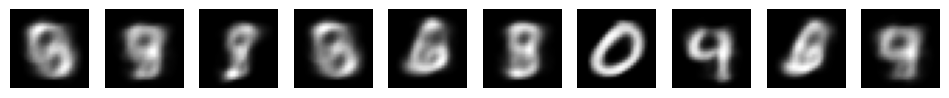

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

latent_dim = 2

encoder_inputs = keras.Input(shape=(784,))
x = layers.Dense(256, activation="relu")(encoder_inputs)
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(256, activation="relu")(latent_inputs)
decoder_outputs = layers.Dense(784, activation="sigmoid")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(
                        tf.expand_dims(data, axis=-1),
                        tf.expand_dims(reconstruction, axis=-1)
                    ),
                    axis=1
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())

(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_train = x_train.reshape((len(x_train), 784))

vae.fit(x_train, epochs=5, batch_size=256, verbose=1)

random_points = np.random.normal(size=(10, latent_dim))
generated_digits = decoder.predict(random_points)

plt.figure(figsize=(12, 2))
for i in range(10):
    ax = plt.subplot(1, 10, i + 1)
    plt.imshow(generated_digits[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.show()

## 8. Referencias y Recursos

- [TensorFlow Autoencoder Tutorial](https://www.tensorflow.org/tutorials/generative/autoencoder)
- [VAE Tutorial - Keras](https://keras.io/examples/generative/vae/)
- Kingma & Welling (2014). *Auto-Encoding Variational Bayes.*

---

📎 **Notebook anterior:** [08. Redes Generativas (GANs)](./08_gans.ipynb)  
📎 **Notebook siguiente:** [10. Clustering y Reducción de Dimensionalidad](./10_clustering_reduccion_dimensionalidad.ipynb)